# Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchmetrics as tm
import torch.nn.functional as F
import seaborn as sns
torch.manual_seed(9497)
import scipy.stats as stats
import plotly.express as px
from pathlib import Path
import umap
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon
import plotly.graph_objects as go
import PyComplexHeatmap as pch

# Model 

In [2]:
from exp_regression import DrugAware_DWM, Transcriptomic_Head, SMILES_Head, CombinedModel
from cli_regressor import Module_training_reg
from utilities import CVDataModule

In [3]:
tx_head = Transcriptomic_Head(
            input_size=946, # 946 | 4377
            hd_1=512,
            hd_2=256
        )

chem_head = SMILES_Head(
    input_size=512,
    hd_1=512, 
    hd_2=256,
    hd_3=128
)

combined_model = CombinedModel(
    input_size=1024,
    hd_1=256, #256
    hd_2=128  #128
)

loss_fn = nn.MSELoss()
lr= 1e-4
wd=0.0

# Data

In [4]:
vector_smiles = pd.read_csv(
    "output/regression/vector_smiles_512.csv",
    index_col=0
)

In [5]:
vector_smiles.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Sunitinib,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PHA-665752,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Cyclopamine,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,0,0
AZ628,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Imatinib,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


## Cell lines

In [6]:
cline_gex = pd.read_csv(
    "output/regression/L1000_GEX_data_filtered_logCPM.csv",
    index_col=0
)

In [7]:
cline_gex.head()

,ABCB6,ABCC5,ABCF1,ABCF3,ABHD4,ABHD6,ABL1,ACAA1,ACAT2,ACBD3,...,ZMIZ1,ZMYM2,ZNF131,ZNF274,ZNF318,ZNF395,ZNF451,ZNF586,ZNF589,ZW10
model_name,,,,,,,,,,,,,,,,,,,,,
22RV1,6.692272,5.974217,5.972175,5.937373,3.905459,2.274118,6.491253,5.258903,6.844647,6.636650,...,4.987584,6.736658,5.452852,4.495404,6.299981,5.998490,6.188324,4.225246,4.699200,5.302827
23132-87,5.811651,5.621582,6.928492,5.869526,6.295594,3.886941,5.921526,5.789106,5.768256,5.802125,...,5.706728,6.679969,5.640479,4.667580,5.517527,5.866943,6.234096,3.788737,4.580018,5.407221
42-MG-BA,6.339612,4.853004,7.245003,5.280296,5.325799,4.142516,7.026414,5.161804,6.125542,6.124434,...,7.336627,4.794387,5.917842,5.280881,4.977325,5.281349,5.257054,2.324235,2.769024,5.603927
451Lu,5.219828,5.896027,6.377211,5.705629,4.042942,4.193596,5.952298,5.341295,5.092637,6.007741,...,6.561371,5.502658,4.866528,3.187331,5.518168,5.420912,4.847967,3.257737,4.093944,4.471016
5637,3.049106,4.826572,7.045027,5.333473,3.510659,1.870316,7.449089,5.054642,6.051388,5.287819,...,6.087544,5.290822,5.164975,4.105767,4.963710,6.145299,4.879865,3.134558,2.752614,5.516239


In [8]:
cline_annotation = pd.read_csv(
    "output/regression/dose_response_matrix.csv",
    index_col=0
)

/tmp/ipykernel_5282/1439493965.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  cline_annotation = pd.read_csv(


In [9]:
cline_annotation.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN


# Cross-validation models to obtain embeddings

In [10]:

root = "output/regression/cross_validation"
cancer_type =  "pancancer"
experiment = "NBS_cells"
fold_dirs = Path(f"{root}/{cancer_type}/{experiment}/")
ckpt_dir = Path(f"cDWM/L1000_{cancer_type}_{experiment}/")

# Sort fold paths in numeric order (fold_0, fold_1, ...)
folds = sorted(fold_dirs.glob("fold_*"), key=lambda x: int(x.name.split("_")[1]))
ckpts = sorted(ckpt_dir.glob("version_*"), key=lambda x: int(x.name.split("_")[1]))

test_l = []
smile_l = []
w_l = []
combined_l = []

#for i in range(10):
    #if i<5:
        
for fold_path, ckpt_path in zip(folds, ckpts):
    fold_name = fold_path.name.split("_")[1]
    ckpt_file = list((ckpt_path / 'checkpoints').glob('*.ckpt'))[0]

    data_module = CVDataModule(
        root=root,
        type=cancer_type,
        experiment=experiment,
        fold_n=fold_name,
        GEX_path="output/regression/L1000_GEX_data_filtered_logCPM.csv",
        SMILES_path="output/regression/vector_smiles_512.csv",
        batch_size=512
    )

    gex, smiles, test_set = data_module.test_dataloader()

    regressor = Module_training_reg.load_from_checkpoint(
    ckpt_file,
    map_location="cpu",
    tx_nn=tx_head,
    chem_nn=chem_head,
    comb_nn=combined_model,
    loss_fn=loss_fn,
    lr=lr,
    weight_decay=wd
    )

    
    ##################################################################################
    #
    #        OBTAINING MATRICES
    #
    ##################################################################################
    y_hat = regressor.predict(gex, smiles)
    test_set["fold_n"] = fold_name
    test_set["y_hat"] = y_hat.double().numpy()
    test_l.append(test_set)

    #---- SMILES ----
    sm_emb = (
        regressor
        .chem_nn
        .predict(smiles)
    )

    #---- GEX ----
    gex_emb = (
        regressor
        .tx_nn
        .predict(gex, sm_emb, mode="predict")
    )
    
    #---- Weight matrix ----
    _ , W = (
        regressor
        .tx_nn
        .predict(gex, sm_emb, mode="exploratory")
    )

    #---- Append to list ----
    sm_emb = pd.DataFrame(
        sm_emb.numpy(),
        index=test_set.DRUG_NAME
    )
    smile_l.append(sm_emb)

    combined_emb = pd.DataFrame(
        gex_emb.numpy() + sm_emb.to_numpy(),
        index = pd.MultiIndex.from_frame(
            test_set.loc[:,["CELL_LINE_NAME", "TCGA_DESC", "DRUG_NAME", "PATHWAY_NAME", "fold_n"]]
        )
    )
    combined_l.append(combined_emb)

    W = pd.DataFrame(
        W.numpy(),
        index=pd.MultiIndex.from_frame(
            test_set[["CELL_LINE_NAME", "TCGA_DESC", "DRUG_NAME", "PATHWAY_NAME", "fold_n"]]
        )
    )
    w_l.append(W)




In [11]:
W = pd.concat(w_l, axis=0)

In [12]:
W.head()

,,,,,0,1,2,3,4,5,6,7,8,9,...,936,937,938,939,940,941,942,943,944,945
CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,fold_n,,,,,,,,,,,,,,,,,,,,,
NCI-H526,SCLC,Sunitinib,RTK signaling,0,0.234602,0.011106,0.080979,0.109743,0.110493,0.988421,0.934527,0.080966,0.924506,0.040904,...,0.000026,0.009261,0.032056,0.016044,0.001427,0.005900,0.014806,0.000076,0.046592,0.000086
LU-139,SCLC,Sunitinib,RTK signaling,0,0.544948,0.012234,0.018355,0.092972,0.036343,0.985092,0.979730,0.010241,0.998462,0.008134,...,0.000014,0.041943,0.000793,0.013570,0.000251,0.001011,0.005380,0.000007,0.380740,0.012563
HCC2157,BRCA,Sunitinib,RTK signaling,0,0.241091,0.370832,0.056775,0.000627,0.026729,0.937478,0.796231,0.512774,0.507399,0.634055,...,0.000021,0.031328,0.000051,0.018385,0.006227,0.009897,0.025925,0.000011,0.339245,0.011743
LB647-SCLC,SCLC,Sunitinib,RTK signaling,0,0.888683,0.013258,0.103510,0.106297,0.060669,0.993560,0.981121,0.018176,0.998139,0.008330,...,0.000008,0.002179,0.004056,0.034413,0.000120,0.001054,0.019910,0.000024,0.147814,0.000889
LU-134-A,SCLC,Sunitinib,RTK signaling,0,0.768292,0.010371,0.115105,0.301431,0.427212,0.992222,0.850735,0.048359,0.991251,0.005214,...,0.000017,0.000511,0.137256,0.048769,0.000088,0.000827,0.012152,0.000103,0.289561,0.000079


In [35]:
W.shape

(343704, 946)

In [36]:
smile_emb = pd.concat(smile_l, axis=0)

In [37]:
smile_emb = smile_emb.loc[~smile_emb.index.duplicated(),:]

In [11]:
cline_dr_data = pd.concat(test_l, axis=0)

In [12]:
cline_dr_data.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET,Y_TRUE,fold_n,y_hat
773,NCI-H526,SCLC,Sunitinib,RTK signaling,3.447551,NaN,0.344070,0,0.280547
780,LU-139,SCLC,Sunitinib,RTK signaling,4.693727,NaN,0.798913,0,0.361654
789,HCC2157,BRCA,Sunitinib,RTK signaling,3.779754,NaN,0.465321,0,0.471545
809,LB647-SCLC,SCLC,Sunitinib,RTK signaling,3.287304,NaN,0.285582,0,0.231016
813,LU-134-A,SCLC,Sunitinib,RTK signaling,3.555525,NaN,0.383480,0,0.505532


In [13]:
cline_dr_data.CELL_LINE_NAME.nunique()

952

In [41]:
(
    cline_dr_data.loc[
    (cline_dr_data.CELL_LINE_NAME=="MCF7")&(cline_dr_data.PATHWAY_NAME=="Hormone-related")
    ,:]
)

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET,Y_TRUE,fold_n,y_hat
286323,MCF7,BRCA,AZD3514,Hormone-related,2.673811,NaN,-0.069270,3,0.230636
68329,MCF7,BRCA,Tamoxifen,Hormone-related,2.691604,ESR1,-0.063941,3,0.287604
69288,MCF7,BRCA,Fulvestrant,Hormone-related,-0.336350,ESR,-0.970808,3,0.195156
152353,MCF7,BRCA,Fulvestrant,Hormone-related,3.301102,ESR,0.118602,3,0.195156
189851,MCF7,BRCA,GDC0810,Hormone-related,2.570747,"ESR1, ESR2",-0.100138,3,0.631693


In [308]:
(
    cline_dr_data
    .loc[cline_dr_data.TCGA_DESC.isin(["BLCA"]), ["TCGA_DESC", "fold_n"]].value_counts()
)

TCGA_DESC  fold_n
BLCA       6         1539
           2         1072
           3          785
           8          751
           0          684
           5          381
           4          381
           1          378
           7          376
           9          337
Name: count, dtype: int64

In [19]:
# blood = ["LCML", "CLL", "MM", "LAML", "ALL", "DLBC", "UNCLASSIFIED"]

In [14]:
cline_prediction = (
    cline_dr_data#.loc[~cline_dr_data.TCGA_DESC.isin(blood),:]
    .pivot_table(
        columns="CELL_LINE_NAME",
        index="DRUG_NAME",
        values="y_hat",
        aggfunc="mean",
        fill_value=1e-6
    )
)

In [15]:
cline_prediction

CELL_LINE_NAME,22RV1,23132-87,42-MG-BA,451Lu,5637,639-V,647-V,697,769-P,786-0,...,WSU-DLCL2,WSU-NHL,YAPC,YH-13,YKG-1,YT,ZR-75-30,huH-1,no-10,no-11
DRUG_NAME,,,,,,,,,,,,,,,,,,,,,
(5Z)-7-Oxozeaenol,-0.375035,-0.434965,-0.653673,-1.503442,-0.607586,-0.746590,-0.606291,-0.942665,-0.753873,-0.801224,...,-0.201443,-0.428168,-0.140677,-0.867813,-0.736288,-0.542554,0.032958,-0.320898,-0.389499,-0.236725
5-Fluorouracil,0.625544,0.369944,0.351308,0.882398,0.625255,0.587908,0.724148,-0.462486,0.217220,0.341516,...,-0.063708,-0.267458,1.455083,0.826601,0.871607,0.041701,1.705003,0.951031,0.794570,1.268757
5-azacytidine,0.045150,0.048645,-0.018835,0.000001,0.219835,0.064995,0.240495,-0.529121,0.029911,-0.009097,...,-0.314151,-0.457222,0.785979,0.098534,0.000001,-0.224686,1.057620,0.332019,0.000001,0.000001
A-366,0.784730,0.836337,0.792365,0.000001,0.892978,0.754464,0.838475,0.222961,0.866931,0.778048,...,0.394619,0.372273,1.405691,0.887586,0.000001,0.514083,1.404053,1.069443,0.000001,0.000001
A-443654,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,-1.716577,0.000001,0.000001,...,-0.568373,-0.900132,0.000001,0.000001,0.000001,-0.937118,0.000001,0.000001,-1.410725,-1.179140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zoledronate,0.406998,0.452563,0.430561,0.000001,0.528478,0.345272,0.463731,-0.087613,0.480634,0.354650,...,0.000001,0.018718,1.051420,0.617002,0.000001,0.000001,0.997394,0.684948,0.000001,0.000001
alpha-lipoic acid,1.736162,1.801682,1.852719,0.000001,1.783820,1.803779,1.823130,1.335054,2.021993,1.801223,...,1.479456,1.611384,2.428087,1.869051,0.000001,1.471897,2.377125,2.026523,0.000001,0.000001
glutathione,2.296613,2.341609,2.350725,0.000001,2.419839,2.346034,2.358165,2.108151,2.653894,2.350508,...,2.167777,2.245288,2.883835,2.364895,0.000001,2.167214,2.825854,2.541596,0.000001,0.000001


In [16]:
cline_pathways =(
    cline_prediction
    .index
    .map(
        cline_dr_data
        .drop_duplicates(subset="DRUG_NAME")
        .set_index("DRUG_NAME").PATHWAY_NAME
        )
)

In [17]:
cline_dr_data["Y_TRUE"] = (
    cline_dr_data["LN_IC50"] - cline_dr_data["LN_IC50"].mean()
) / cline_dr_data["LN_IC50"].std() 

In [18]:
cline_measured = (
    cline_dr_data#.loc[~cline_dr_data.TCGA_DESC.isin(blood),:]
    .pivot_table(
        columns="CELL_LINE_NAME",
        index="DRUG_NAME",
        values="Y_TRUE",
        aggfunc="mean",
        fill_value=1e-6
    )
)

## UMAP drugs x cell lines

<Axes: >

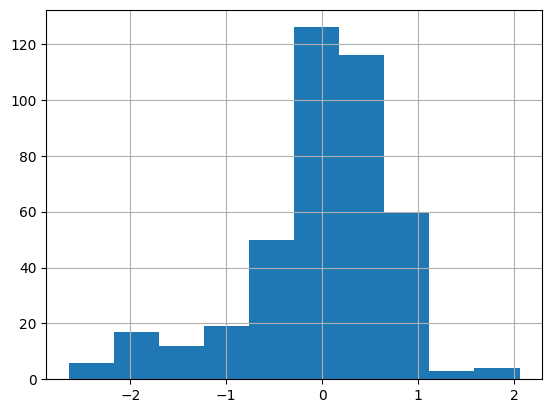

In [219]:
cline_prediction.mean(axis=1).hist()

In [18]:
q25, q75 = np.percentile(cline_prediction.mean(axis=1), [25, 75])

In [19]:
q25

np.float64(-0.29280417847251)

In [20]:
q75

np.float64(0.5088038072700032)

In [22]:
# drug_mean = cline_prediction.mean(axis=1)
drug_mean = cline_measured.mean(axis=1)

In [47]:
drug_mean

DRUG_NAME
(5Z)-7-Oxozeaenol   -0.561592
5-Fluorouracil       0.674668
5-azacytidine        0.130099
A-366                0.652773
A-443654            -0.482943
                       ...   
Zoledronate          0.360602
alpha-lipoic acid    1.410808
glutathione          1.820658
kb NB 142-70         0.013573
torin2              -0.238394
Length: 413, dtype: float64

In [28]:
sensitive = drug_mean<q25

resistant = drug_mean>q75

In [29]:
response_color_cline = pd.Series("", index=drug_mean.index)

response_color_cline[sensitive] = "sensitive"
response_color_cline[resistant] = "resistant"

response_color_cline.value_counts()

             207
sensitive    103
resistant    103
Name: count, dtype: int64

In [30]:
color_map_sensitivity = {
    "sensitive" : "blue",
    "resistant" : "red",
    "" : "grey"
}

In [19]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    n_components=2,
)

In [48]:
del reducer

In [20]:

z_umap = reducer.fit_transform(cline_prediction)


/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
(
    drug_mean.abs() * 10
).describe()

count    413.000000
mean       5.406137
std        5.019012
min        0.005389
25%        1.732223
50%        4.097551
75%        7.413877
max       25.831028
dtype: float64

In [25]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=drug_mean, # response_color_cline
                 size=drug_mean.abs()*10,
                 size_max=20,
                 height=500,
                 width=500,
                 # color_discrete_map=color_map_sensitivity,
                 color_continuous_scale="PuOr_r",
                 range_color=(-2,2),
                 # category_orders={"color": category_order},
                 # hover_data=[cline_pathways] ,
                 template="simple_white",
                #  title= "Embedding with blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color" : "Response"
                       },
               )

fig.update_traces(
    marker=dict(
        # size=8,
        line=dict(width=1, color="DarkSlateGrey")
    )
)

fig.update_layout(font=dict(size=16, family="Helvetica"))
fig.update_yaxes(scaleanchor="x")

# fig.update_layout(
#     showlegend=True,
#     legend=dict(
#         orientation="h",           # horizontal layout
#         yanchor="top",
#         y=1.2,                    # move it below the plot
#         xanchor="center",
#         x=0.5                      # center it horizontally
#     )
# )

fig.update_layout(
    coloraxis_colorbar=dict(
        orientation="h",
        x=0.02,
        y=1.05,
        xanchor="left",
        yanchor="bottom",
        len=1,
        thickness=15
    )
)

In [26]:
# fig.write_image("slides/figures_regression/benchmark/drug_CCL_UMAP.pdf")

Below is the visualization of predicted IC50s from TCGA PDOs and predicted IC50s for CCL. This is done by computing UMAP independently and then vstack the reduced space

<Axes: >

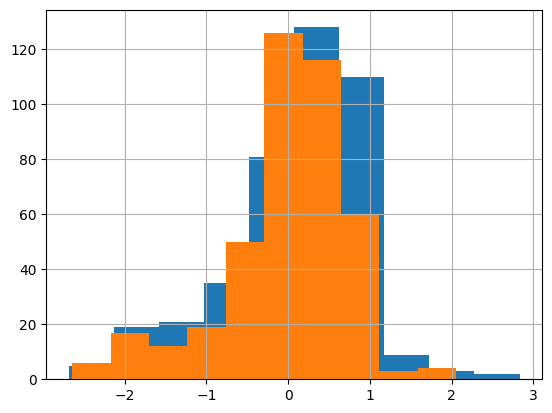

In [395]:
tcga_prediction.mean(axis=1).hist()
cline_prediction.mean(axis=1).hist()

In [396]:
tcga_prediction.mean(axis=1).describe()

count    413.000000
mean       0.146000
std        0.853319
min       -2.686198
25%       -0.239667
50%        0.265529
75%        0.731970
max        2.832637
dtype: float64

In [397]:
q25, q75 = np.percentile(tcga_prediction.mean(axis=1), [25, 75])

In [398]:
drug_mean = tcga_prediction.mean(axis=1)

In [399]:
sensitive = drug_mean<q25

resistant = drug_mean>q75

In [400]:
response_color_tcga = pd.Series("", index=drug_mean.index)

response_color_tcga[sensitive] = "sensitive"
response_color_tcga[resistant] = "resistant"

response_color_tcga.value_counts()

             207
sensitive    103
resistant    103
Name: count, dtype: int64

In [401]:
response_color = pd.concat([response_color_cline, response_color_tcga], axis=0)

In [402]:
len(response_color)

826

In [403]:
model_type = pd.concat(
    [pd.Series(["CCL"] * len(response_color_cline)),
    pd.Series(["PDO"]* len(response_color_tcga))]
)

In [404]:
len(model_type)

826

In [410]:
umap_pdo = reducer.transform(tcga_prediction)

# Combine embeddings
Z_all = np.vstack([z_umap, umap_pdo])

In [411]:
Z_all.shape

(826, 2)

In [417]:
fig = px.scatter(Z_all,
                 x=0,
                 y=1,
                 color=response_color,
                 symbol=model_type,
                 height=600,
                 width=600,
                 # opacity=0.5,
                 color_discrete_map=color_map_sensitivity,
                 # category_orders={"color": category_order},
                 # hover_data=[cline_pathways] ,
                 template="simple_white",
                #  title= "Embedding with blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color" : "Sensitivity"
                       },
               )

fig.update_traces(
    marker=dict(
        size=8,
        line=dict(width=1, color="DarkSlateGrey")
    )
)


fig.update_traces(
    marker=dict(size=10, line=dict(width=1)),
    selector=dict(marker_symbol="diamond")
)
fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=True,
    legend=dict(
        orientation="h",           # horizontal layout
        yanchor="bottom",
        y=-0.5,                    # move it below the plot
        xanchor="center",
        x=0.5                      # center it horizontally
    )
)


In [418]:
# fig.write_image("slides/figures_regression/benchmark/PDO_projection_CCL.pdf")

In [200]:
Z_all.shape

(826, 5)

In [ ]:
# fig = px.scatter_3d(Z_all,
#                  x=0,
#                  y=2,
#                  z=4,
#                  color=response_color,
#                  symbol=model_type,
#                  height=600,
#                  width=600,
#                  opacity=0.5,
#                  color_discrete_map=color_map_sensitivity,
#                  # category_orders={"color": category_order},
#                  # hover_data=[cline_pathways] ,
#                  template="simple_white",
#                 #  title= "Embedding with blood cancers",
#                  labels={"0": "UMAP 1",
#                         "1": "UMAP 2",
#                         "color" : "Sensitivity"
#                        },
#                )

# fig.update_traces(marker=dict(size=2))
# fig.update_traces(
#     marker=dict(size=4, line=dict(width=1)),
#     selector=dict(marker_symbol="diamond")
# )
# fig.update_layout(font=dict(size=16))
# fig.update_yaxes(scaleanchor="x")
# fig.update_layout(
#     showlegend=False,
#     legend=dict(
#         orientation="h",           # horizontal layout
#         yanchor="bottom",
#         y=-0.2,                    # move it below the plot
#         xanchor="center",
#         x=0.5                      # center it horizontally
#     )
# )


In [351]:
# fig.write_image("3d_umap.svg")

## UMAP embedding space of cell lines-drugs

In [44]:
combined_emb = pd.concat(combined_l, axis=0)

In [45]:
combined_emb.head()

,,,,,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,fold_n,,,,,,,,,,,,,,,,,,,,,
NCI-H526,SCLC,Sunitinib,RTK signaling,0,1.069107,-0.273117,-1.465119,-0.590063,1.038244,0.410872,0.527613,-0.331887,-1.486220,-0.538440,...,-0.883385,-0.074895,-0.858313,-0.294539,-0.548503,1.499929,-0.525834,1.329932,-0.515514,1.706597
LU-139,SCLC,Sunitinib,RTK signaling,0,0.829922,0.168603,-1.498747,-0.727645,0.812140,0.546693,0.135951,-0.350499,-1.493251,-0.740064,...,-0.238401,0.115282,-0.589082,-0.607210,-0.021012,1.359037,-0.306547,0.805837,0.000684,1.735747
HCC2157,BRCA,Sunitinib,RTK signaling,0,0.332757,-0.116787,-0.847002,-0.173949,0.923764,0.717027,0.322557,0.313042,-1.337965,-0.547529,...,-0.266847,-0.082925,-1.258178,0.049794,-0.989052,1.405406,0.120554,1.422417,-0.729441,1.449213
LB647-SCLC,SCLC,Sunitinib,RTK signaling,0,1.143503,-0.148601,-1.506820,-0.444554,0.761283,0.625130,0.137223,-0.383986,-1.489290,-0.683180,...,-0.269948,0.016206,-0.342983,-0.456777,-0.045897,1.577341,-0.722604,0.961324,-0.264496,1.739993
LU-134-A,SCLC,Sunitinib,RTK signaling,0,1.189644,-0.224794,-1.520014,-0.678934,1.081617,0.103096,0.321817,-0.335667,-1.499440,-0.526205,...,-1.086051,-0.940204,-0.947036,-0.252538,-0.991391,1.281460,-0.469020,0.855450,-1.031027,1.728913


In [58]:
combined_emb = combined_emb.loc[
combined_emb.index.get_level_values("TCGA_DESC")!="UNCLASSIFIED", :
]

In [110]:
unknown_drugs = ["Other, kinases", "Other", "Unclassified"]

In [112]:
combined_emb = (
    combined_emb.loc[
    ~combined_emb.index.get_level_values("PATHWAY_NAME").isin(unknown_drugs), :
]
)

In [86]:
cline_dr_data = (
    cline_dr_data.loc[
    cline_dr_data.TCGA_DESC!="UNCLASSIFIED",:
    ]
)

In [113]:
cline_dr_data = (
    cline_dr_data.loc[
    ~cline_dr_data.PATHWAY_NAME.isin(unknown_drugs),:
    ]
)

In [41]:
data = {
    "Cancer_Type": [
        "LUAD", "COREAD", "PAAD", "PRAD", "THCA", "UCEC", "LIHC", "BRCA",
        "ESCA", "STAD", "COAD",
        "HNSC", "LUSC", "CESC", "SCLC",
        "LAML", "ALL", "LCML", "CLL", "DLBC",
        "BLCA", "MESO", "ACC", "OV",
        "KIRC", "KIRP", "SKCM", "MM",
        "GBM", "LGG", "MB", "NB",
        "UNCLASSIFIED", "LUAD/LUSC"
    ],
    "Histopathology": [
        "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma",
        "Adenocarcinoma", "Adenocarcinoma", "Adenocarcinoma",
        "Squamous cell carcinoma", "Squamous cell carcinoma", "Squamous cell carcinoma", "Squamous cell carcinoma",
        "Leukemia", "Leukemia", "Leukemia", "Leukemia", "Lymphoma",
        "Other carcinoma", "Other carcinoma", "Other carcinoma", "Other carcinoma",
        "Other carcinoma", "Other carcinoma", "Other carcinoma", "Hematologic",
        "Brain-related", "Brain-related", "Brain-related", "Brain-related",
        "UNCLASSIFIED", "Other carcinoma"
    ]
}

histopathology_df = pd.DataFrame(data)

In [42]:
histopathology_colors = {
    # carcinomas → blues
    "Squamous cell carcinoma": "#1f77b4",
    "Adenocarcinoma":          "#3b82f6",
    "Other carcinoma":         "#89b4f8",
    
    # blood-related → purples
    "Leukemia":    "#7b3294",
    "Hematologic": "#9e77d8",
    "Lymphoma":    "#c2a5cf",
    
    "Brain-related": "#499931",
    "UNCLASSIFIED": "lightgrey",  # grey #f5f5f5 #808080
}

In [114]:
histo = (
    combined_emb.index.get_level_values("TCGA_DESC")
    .map(histopathology_df.set_index("Cancer_Type").Histopathology)
)

In [115]:
del reducer

In [116]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    metric="euclidean"
)

In [117]:

# z_umap = reducer.fit_transform(pca.fit_transform(combined_emb))

z_umap = reducer.fit_transform(combined_emb)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [150]:
histo_order = [
    "Squamous cell carcinoma",
    "Adenocarcinoma",
    "Other carcinoma",
    "Brain-related",
    "Leukemia",
    "Hematologic",
    "Lymphoma"
]

In [ ]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=histo,
                 height=700,
                 width=700,
                 color_discrete_map=histopathology_colors,
                 category_orders={"color": histo_order},
                 # hover_data=[cline_desc] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"Histopathology"
                       },
               )
fig.update_traces(marker=dict(size=2.5))
fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=False,
    legend=dict(
        orientation="v",           # horizontal layout
        yanchor="top",
        y=0.8,                    # move it below the plot
        xanchor="right",
        x=1.5                     # center it horizontally
    )
)

fig.update_layout(
    legend=dict(
        itemsizing="constant"    # ensures legend markers obey marker.size
    )
)

fig.update_traces(
    marker=dict(size=10),        # legend marker size
    selector=dict(mode='legend')
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/combined_embedding/UMAP_comb_emb_histo_nolegend.pdf"
# )

In [ ]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=combined_emb.index.get_level_values("PATHWAY_NAME"),
                 height=700,
                 width=700,
                 color_discrete_map=color_pathway,
                 category_orders={"color": pathway_order},
                 # hover_data=[cline_desc] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"Target pathway"
                       },
               )
fig.update_traces(marker=dict(size=2.5))
fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=False,
    legend=dict(
        orientation="v",           # horizontal layout
        yanchor="top",
        y=1,                    # move it below the plot
        xanchor="center",
        x=1.3                    # center it horizontally
    )
)

fig.update_layout(
    legend=dict(
        itemsizing="constant"    # ensures legend markers obey marker.size
    )
)

fig.update_traces(
    marker=dict(size=10),        # legend marker size
    selector=dict(mode='legend')
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/combined_embedding/UMAP_comb_emb_pathway_nolegend.pdf"
# )

In [ ]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=cline_dr_data.Y_TRUE,
                 color_continuous_scale="PuOr",
                 height=700,
                 width=700,
                 # color_discrete_map=histopathology_colors,
                 # hover_data=[cline_desc] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"Z-score ln(IC50)"
                       },
               )
fig.update_traces(
    marker=dict(
        size=2.5,
        # line=dict(width=.2, color="DarkSlateGrey")
    )
)
fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    coloraxis_colorbar=dict(
        orientation="h",
        x=0.3,       # horizontal position (0 = left, 1 = right)
        y=1.2,        # vertical position  (0 = bottom, 1 = top)
        xanchor="center",
        yanchor="top",
        len=0.7,      # length of the bar
        thickness=15  # width of the bar
    )
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/combined_embedding/UMAP_comb_emb_IC50.pdf"
# )

In [202]:
ckpt_file = "cDWM/L1000_pancancer_NBS_cells/version_0/checkpoints/epoch=99-step=48300.ckpt"

regressor = Module_training_reg.load_from_checkpoint(
    ckpt_file,
    map_location="cpu",
    tx_nn=tx_head,
    chem_nn=chem_head,
    comb_nn=combined_model,
    loss_fn=loss_fn,
    lr=lr,
    weight_decay=wd
    )

In [249]:
pdo_metadata = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

pdo_metadata["z_score_ic50"] = (
    pdo_metadata.groupby("Line")["LogIC50"]
    .transform(lambda x: stats.zscore(x, nan_policy="omit"))
)

pdo_metadata = pdo_metadata.loc[pdo_metadata.seen_before=="yes",:]

pdo_metadata["model_type"] = "Benchmarking_PDO"

pdo_metadata = (
    pdo_metadata.loc[:,["Line",
                        "TCGA_DESC",
                        "Drug",
                        "LogIC50",
                        "z_score_ic50",
                        "PATHWAY_NAME",
                        "model_type"
                       ]]
)

pdo_metadata.columns = [
    "model_name",
    "TCGA_DESC",
    "Drug",
    "LogIC50",
    "z_score_ic50",
    "PATHWAY_NAME",
    "model_type"
]

In [209]:
sm = (
    torch.tensor(
        vector_smiles.loc[pdo_metadata.Drug, :].to_numpy(), dtype=torch.float32
    )
)
sm_emb = (
    regressor
    .chem_nn
    .predict(sm)
)

In [210]:
pdo_gex = pdo_gex.loc[pdo_metadata.model_name,:]
pdo_gex_scaled = (pdo_gex-tx_mean)/tx_std
pdo_gex_scaled = (
    torch.tensor(
        pdo_gex.to_numpy(), dtype=torch.float32
    )
)

pdo_gex_emb = (
    regressor
    .tx_nn
    .predict(pdo_gex_scaled, sm_emb)
)

In [212]:
combined_emb.head()

,,,,,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,fold_n,,,,,,,,,,,,,,,,,,,,,
NCI-H526,SCLC,Sunitinib,RTK signaling,0,1.069107,-0.273117,-1.465119,-0.590063,1.038244,0.410872,0.527613,-0.331887,-1.486220,-0.538440,...,-0.883385,-0.074895,-0.858313,-0.294539,-0.548503,1.499929,-0.525834,1.329932,-0.515514,1.706597
LU-139,SCLC,Sunitinib,RTK signaling,0,0.829922,0.168603,-1.498747,-0.727645,0.812140,0.546693,0.135951,-0.350499,-1.493251,-0.740064,...,-0.238401,0.115282,-0.589082,-0.607210,-0.021012,1.359037,-0.306547,0.805837,0.000684,1.735747
HCC2157,BRCA,Sunitinib,RTK signaling,0,0.332757,-0.116787,-0.847002,-0.173949,0.923764,0.717027,0.322557,0.313042,-1.337965,-0.547529,...,-0.266847,-0.082925,-1.258178,0.049794,-0.989052,1.405406,0.120554,1.422417,-0.729441,1.449213
LB647-SCLC,SCLC,Sunitinib,RTK signaling,0,1.143503,-0.148601,-1.506820,-0.444554,0.761283,0.625130,0.137223,-0.383986,-1.489290,-0.683180,...,-0.269948,0.016206,-0.342983,-0.456777,-0.045897,1.577341,-0.722604,0.961324,-0.264496,1.739993
LU-134-A,SCLC,Sunitinib,RTK signaling,0,1.189644,-0.224794,-1.520014,-0.678934,1.081617,0.103096,0.321817,-0.335667,-1.499440,-0.526205,...,-1.086051,-0.940204,-0.947036,-0.252538,-0.991391,1.281460,-0.469020,0.855450,-1.031027,1.728913


In [213]:
z_pdo = pd.DataFrame(pdo_gex_emb.numpy()+sm_emb.numpy())
z_pdo.index = pd.MultiIndex.from_frame(
    pdo_metadata[["model_name", "TCGA_DESC", "PATHWAY_NAME"]]
)

In [214]:
z_pdo.head()

,,,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
model_name,TCGA_DESC,PATHWAY_NAME,,,,,,,,,,,,,,,,,,,,,
P9-M-LN,HNSC,DNA replication,1.762385,-1.446664,0.166693,1.320353,-0.186184,1.300585,-1.362550,1.773418,-0.677300,-0.040053,...,-1.351464,-0.442648,0.133857,0.435756,-1.023432,0.381430,1.714731,0.334447,0.715134,-0.070302
P20-T-G,HNSC,DNA replication,1.825054,-1.448466,0.056168,1.528130,-0.432173,1.097830,-1.484099,1.787271,-0.684787,-0.027322,...,-1.161497,0.038511,0.139047,0.248579,-1.089166,0.126718,1.735590,0.715602,0.721806,-0.680317
P47-T-T,HNSC,DNA replication,1.530005,-1.448502,0.323254,1.492774,-0.684693,1.113980,-1.476892,1.761981,-0.654865,-0.134342,...,-1.655534,-0.144608,0.135305,0.159032,-1.087782,0.309163,1.661327,0.039506,0.722713,-0.484244
P47-R-AP,HNSC,DNA replication,1.451026,-1.447347,0.203875,1.135356,-0.601727,1.346733,-1.294184,1.739786,-0.709011,-0.268269,...,-1.535762,-0.469213,0.133642,0.625300,-1.071737,0.460081,1.614363,-0.035047,0.733643,0.345011
P48-M-LN,HNSC,DNA replication,1.341116,-1.448850,0.536128,1.855537,-1.113454,1.063370,-0.737697,1.714155,-0.741932,-0.008198,...,-1.525922,-0.460847,0.020087,0.104686,-0.632887,1.851593,1.488990,0.434718,0.654770,-0.054613


In [255]:
del reducer

In [256]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    metric="euclidean"
)

In [217]:
z_pdo_umap = reducer.fit_transform(z_pdo)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [257]:
z_ccl_pdo_umap = (
    reducer.fit_transform(
        np.vstack([combined_emb.to_numpy(), z_pdo.to_numpy()])
    )
)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [262]:
z_ccl_pdo_umap.shape

(210681, 2)

In [271]:
color = (
    np.hstack([
        cline_dr_data.Y_TRUE.to_numpy(), pdo_metadata.z_score_ic50.to_numpy()
    ])
)

In [283]:
shape = ["CCL"]* combined_emb.shape[0] + ["PDO"]*pdo_gex_emb.shape[0]

In [284]:
len(shape)

210681

In [ ]:
fig = px.scatter(z_ccl_pdo_umap,
                 x=0,
                 y=1,
                 color=color,
                 color_continuous_scale="PuOr",
                 range_color=(-4,4),
                 color_continuous_midpoint=0,
                 symbol=shape,
                 height=500,
                 width=500,
                 # color_discrete_map=histopathology_colors,
                 # hover_data=[
                 #     pdo_metadata.model_name,
                 #     pdo_metadata.Drug
                 # ] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"Z-score ln(IC50)"
                       },
               )
fig.update_traces(
    marker=dict(
        size=2.5,
        # line=dict(width=.2, color="DarkSlateGrey")
    )
)
fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    coloraxis_colorbar=dict(
        orientation="h",
        x=0.3,       # horizontal position (0 = left, 1 = right)
        y=1.2,        # vertical position  (0 = bottom, 1 = top)
        xanchor="center",
        yanchor="top",
        len=0.9,      # length of the bar
        thickness=15  # width of the bar
    )
)


## UMAP SMILES embedding

In [105]:
color_pathway = {
    # Signaling - blues
    "PI3K/MTOR signaling": "#084594",      # strong navy blue
    "RTK signaling": "#2171b5",           
    "EGFR signaling": "#4292c6",
    "ERK MAPK signaling": "#6baed6",
    "WNT signaling": "#0033FF",
    "IGF1R signaling": "#1d91c0",
    "JNK and p38 signaling": "#0b559f",
    "ABL signaling": "#08306b",

    # Chromatin - purples
    "Chromatin histone methylation": "#54278f",  # deep purple
    "Chromatin histone acetylation": "#6a51a3",
    "Chromatin other": "#807dba",

    # Cell cycle / DNA - greens
    "Cell cycle": "#00A845",           # forest green
    "Mitosis": "#238b45",
    "DNA replication": "#41ab5d",
    "Genome integrity": "#74c476",

    # Apoptosis / p53 / degradation - reds
    "Apoptosis regulation": "#a50f15",   # rich blood red
    "p53 pathway": "#cb181d",
    "Protein stability and degradation": "#FF6A00",

    # Metabolism / hormone - orange/yellow
    "Metabolism": "#f16913",            # strong orange
    "Hormone-related": "#d94801",

    # Other / Unclassified - neutral
   "Other, kinases": "#525252",        # dark gray
    "Other": "#737373",
    "Unclassified": "#969696",
    "Cytoskeleton": "#4e9a06"
}


In [106]:
pathway_order = [
    # Signaling (strong blues)
    "PI3K/MTOR signaling", "RTK signaling", "EGFR signaling", "ERK MAPK signaling",
    "WNT signaling", "IGF1R signaling", "JNK and p38 signaling", "ABL signaling",
    
    # Chromatin / Epigenetic (strong purples)
    "Chromatin histone methylation", "Chromatin histone acetylation", "Chromatin other",

    # Cell Cycle / DNA / Genome (greens)
    "Cell cycle", "Mitosis", "DNA replication", "Genome integrity", "Cytoskeleton",

    # Apoptosis / Stress / p53 / Degradation (reds)
    "Apoptosis regulation", "p53 pathway", "Protein stability and degradation",

    # Metabolism / Hormone (oranges)
    "Metabolism", "Hormone-related",

    # Other (grays)
    "Other, kinases", "Other", "Unclassified"
]


In [47]:
cline_dr_data.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET,Y_TRUE,fold_n,y_hat
773,NCI-H526,SCLC,Sunitinib,RTK signaling,3.447551,NaN,0.344070,0,0.384148
780,LU-139,SCLC,Sunitinib,RTK signaling,4.693727,NaN,0.798913,0,0.065344
789,HCC2157,BRCA,Sunitinib,RTK signaling,3.779754,NaN,0.465321,0,0.329869
809,LB647-SCLC,SCLC,Sunitinib,RTK signaling,3.287304,NaN,0.285582,0,0.180402
813,LU-134-A,SCLC,Sunitinib,RTK signaling,3.555525,NaN,0.383480,0,0.461722


In [106]:
del reducer

In [107]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    metric="euclidean"
)

In [51]:
smiles_pathway=(
    smile_emb
    .index
    .map(cline_dr_data
         .drop_duplicates(subset="DRUG_NAME")
         .set_index("DRUG_NAME").PATHWAY_NAME)
)

In [80]:
GREY = "grey" #"#EAEAEA"
keep = {"WNT signaling",
       "Cell cycle",
        "Protein stability and degradation",
       }

colors_greyed = {k: (v if k in keep else GREY) for k, v in color_pathway.items()}

In [108]:

# z_umap = reducer.fit_transform(pca.fit_transform(z_concat))

z_umap = reducer.fit_transform(smile_emb)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [110]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=smiles_pathway,
                 height=500,
                 width=500,
                 opacity=0.5,
                 color_discrete_map=colors_greyed,
                 category_orders={"color": pathway_order},
                 hover_data=[smile_emb.index] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"Target pathway"
                       },
               )

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=1, color="DarkSlateGrey")
    )
)

fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=False,
    legend=dict(
        orientation="h",           # horizontal layout
        yanchor="bottom",
        y=-1,                    # move it below the plot
        xanchor="center",
        x=0.5                      # center it horizontally
    )
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/SMILES_UMAP.pdf"
# )

## UMAP weight matrix

| Hex       | Approx. name      |
| --------- | ----------------- |
| `#a6cee3` | light sky blue    |
| `#1f78b4` | denim blue        |
| `#b2df8a` | light olive green |
| `#33a02c` | forest green      |
| `#fb9a99` | salmon pink       |
| `#e31a1c` | crimson red       |
| `#fdbf6f` | sandy orange      |
| `#ff7f00` | bright orange     |
| `#cab2d6` | lavender purple   |
| `#6a3d9a` | deep violet       |
| `#ffff99` | pale yellow       |
| `#b15928` | chestnut brown    |


In [13]:
W.index.get_level_values("PATHWAY_NAME").value_counts()

PATHWAY_NAME
Other                                38258
PI3K/MTOR signaling                  37718
Other, kinases                       34941
RTK signaling                        29226
DNA replication                      22573
Chromatin histone acetylation        16736
ERK MAPK signaling                   15130
Cell cycle                           15022
Genome integrity                     14589
Apoptosis regulation                 13992
Mitosis                              12389
Chromatin other                      10910
Chromatin histone methylation        10642
Unclassified                          9767
EGFR signaling                        8335
WNT signaling                         8317
Metabolism                            8172
Protein stability and degradation     7774
Cytoskeleton                          7326
JNK and p38 signaling                 5877
p53 pathway                           5412
IGF1R signaling                       4667
Hormone-related                       460

In [38]:
wnt_set = W.xs("WNT signaling", level="PATHWAY_NAME")

In [39]:
wnt_inhibitors = ["Wnt-C59", "LGK974", "IWP-2",
                  "MN-64", "XAV939", "WIKI4", "AZ6102"
                 ]

In [40]:
wnt_set = (
    wnt_set.loc[wnt_set.index.get_level_values("DRUG_NAME").isin(wnt_inhibitors),:]
)

In [41]:
wnt_moa = pd.DataFrame(
    {
        "drug":["IWP-2", "LGK974", "Wnt-C59",
                "MN-64", "XAV939", "AZ6102", "WIKI4"
               ],
        "MoA": ["PORCNi", "PORCNi", "PORCNi",
                "TNKSi", "TNKSi", "TNKSi", "TNKSi"
               ]
    }
)

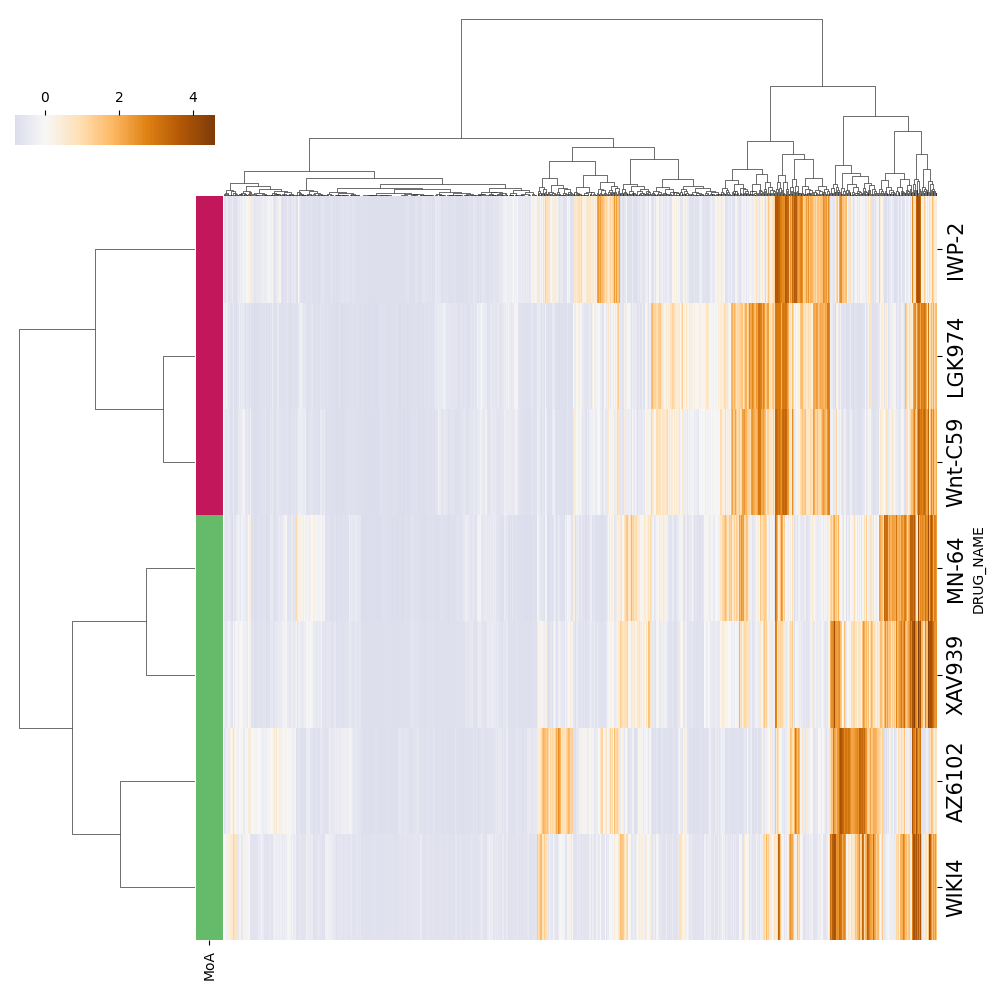

In [47]:
unique_class = wnt_moa.MoA.unique()
# palette = sns.color_palette("Accent", len(unique_class))
palette = [
    "#C2185B",  # light magenta
    "#66BB6A" # light green
] 


map = dict(zip(unique_class, palette))
row_color = wnt_moa.set_index("drug")["MoA"].map(map)

g = sns.clustermap(
    wnt_set.groupby("DRUG_NAME").median(),
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r",
    standard_scale=None,
    z_score=0,
    center=0,
    method="ward",
    metric="euclidean",
    xticklabels=False,
    row_colors=row_color,
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.85, 0.2, 0.03)
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), va='center')

g

In [48]:
# g.fig.savefig(
#     "slides/figures_regression/benchmark/WNTi_clustermap.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

In [90]:
wnt_set = wnt_set.xs("0", level="fold_n")

In [91]:
MoA_wnt = (
    wnt_set.index.get_level_values("DRUG_NAME")
    .map(wnt_moa.set_index("drug")["MoA"])
)

In [113]:
del reducer

In [114]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    metric="cosine",
    n_components=2
)

In [115]:
z_umap = reducer.fit_transform(wnt_set)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [116]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=MoA_wnt,
                 height=500,
                 width=500,
                 # opacity=0.7,
                 color_discrete_map=map,
                 # category_orders={"color": category_order},
                 # hover_data=[df.columns] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"MoA"
                       },
               )

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=0.5, color="DarkSlateGrey")
    )
)

fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=True,
    legend=dict(
        orientation="v",
        y=0.5,
        x=1
    )
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/WNTi_UMAP.pdf"
# )

In [26]:
prot_set = W.xs("Protein stability and degradation", level="PATHWAY_NAME")

In [20]:
prot_set.index.get_level_values("DRUG_NAME").value_counts()

DRUG_NAME
MG-132          943
Luminespib      938
P22077          932
Bortezomib      931
Tanespimycin    924
Lenalidomide    924
SNX-2112        881
ML323           867
CCT-018159      217
Elesclomol      217
Name: count, dtype: int64

In [27]:
no_prot_stab = [
    "CCT-018159", "Elesclomol"
]

In [28]:
prot_set = (
    prot_set.loc[~prot_set.index.get_level_values("DRUG_NAME").isin(no_prot_stab), :]
)

In [29]:
prot_moa = pd.DataFrame(
    {
        "drug":["MG-132", "Tanespimycin", "Bortezomib",
                "Luminespib", "SNX-2112",
                "ML323", "Lenalidomide", "P22077"
               ],
        "MoA": ["HSP/Proteasome", "HSP/Proteasome", "HSP/Proteasome",
                "HSP/Proteasome","HSP/Proteasome",
                "Ubiquitin system", "Ubiquitin system", "Ubiquitin system"
               ]
    }
)

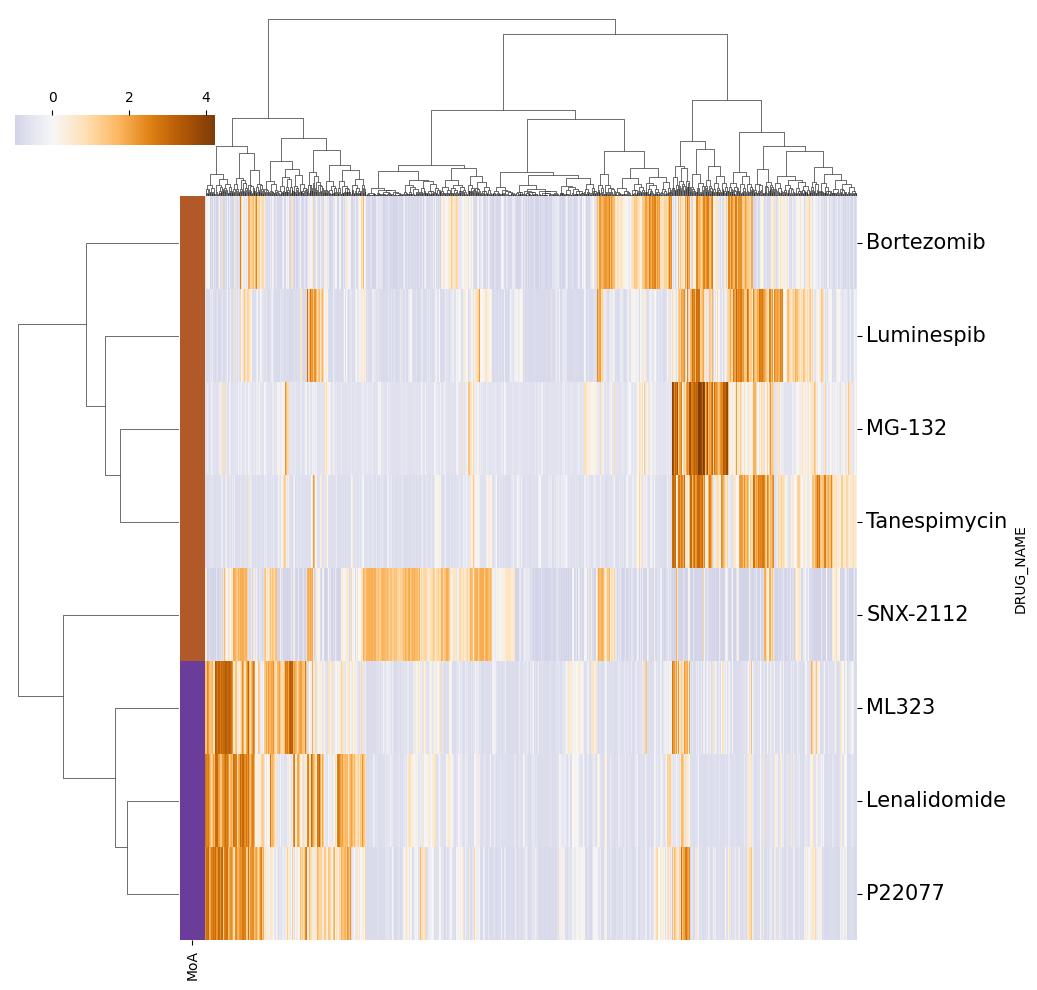

In [49]:
unique_class = prot_moa.MoA.unique()
# palette = sns.color_palette("Accent", len(unique_class))
palette = [
    "#b15928",
    "#6a3d9a"
] 

map = dict(zip(unique_class, palette))
row_color = prot_moa.set_index("drug")["MoA"].map(map)

g = sns.clustermap(
    prot_set.groupby("DRUG_NAME").median(),
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r",
    standard_scale=None,
    z_score=0,
    center=0,
    method="ward",
    metric="euclidean",
    xticklabels=False,
    row_colors=row_color,
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.85, 0.2, 0.03)
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), va='center')

g

In [50]:
# g.fig.savefig(
#     "slides/figures_regression/benchmark/proteasome_clustermap.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

In [103]:
del reducer

In [104]:
reducer = umap.UMAP(
    init="pca",
    random_state=14,
    metric="cosine"
)

In [105]:
prot_set = prot_set.xs("0", level="fold_n")
z_umap = reducer.fit_transform(prot_set)

/media/christian97/Data/PhD/drug_repurposing/venv_drug_repurposing/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [106]:
MoA_prot = (
    prot_set.index.get_level_values("DRUG_NAME")
    .map(prot_moa.set_index("drug")["MoA"])
)

In [107]:
fig = px.scatter(z_umap,
                 x=0,
                 y=1,
                 color=MoA_prot,
                 height=500,
                 width=500,
                 # opacity=0.5,
                 color_discrete_map=map,
                 # category_orders={"color": category_order},
                 # hover_data=[z_concat.index.get_level_values("TCGA_DESC")] ,
                 template="simple_white",
                #  title= "Embedding without blood cancers",
                 labels={"0": "UMAP 1",
                        "1": "UMAP 2",
                        "color":"MoA"
                       },
               )

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=0.5, color="DarkSlateGrey")
    )
)

fig.update_layout(font=dict(size=16))
fig.update_yaxes(scaleanchor="x")
fig.update_layout(
    showlegend=True,
    legend=dict(
        orientation="h",           # horizontal layout
        yanchor="top",
        y=1.1,                    # move it below the plot
        xanchor="center",
        x=0.5                      # center it horizontally
    )
)


In [ ]:
# fig.write_image(
#     "slides/figures_regression/benchmark/proteasome_UMAP.pdf"
# )